# Credit Risk & Loan Default Prediction System
## Intermediate ML Project | Real-World Financial Dataset

### Project Objective
To analyze customer financial data and build machine learning models that predict loan default, helping financial institutions reduce risk and make smarter lending decisions.

### Key Sections:
1. **Data Loading & Preprocessing** - Handle missing values, encode categories, treat outliers
2. **Exploratory Data Analysis (EDA)** - Understand patterns and relationships in data
3. **Feature Engineering** - Create risk indicators from raw features
4. **Model Building & Comparison** - Train and evaluate multiple ML models
5. **Model Explainability** - Understand WHY the model makes predictions
6. **Business Insights & Recommendations** - Actionable insights for decision-making

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset (robust)
try:
    df = pd.read_csv('Loan_default.csv')
    print("Dataset shape:", df.shape)
    print("\nFirst few rows:")
    print(df.head())
except FileNotFoundError:
    raise FileNotFoundError("Loan_default.csv not found in the project folder. Please add the CSV or update the path.")

# Data info (concise)
print("\nData dtypes summary:\n", df.dtypes.value_counts())

# 1. Handling Missing Values
print("\nMissing values (top):")
print(df.isnull().sum().loc[lambda x: x>0].head(20))

# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# 2. Encoding Categorical Variables (safe)
le_dict = {}
for col in categorical_cols:
    try:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
    except Exception as e:
        print(f"Encoding failed for {col}: {e}")

# 3. Outlier Treatment (Log Transformation for Income)
if 'Income' in df.columns:
    df['Income_Log'] = np.log(df['Income'].fillna(0) + 1)
if 'CoApplicantIncome' in df.columns:
    df['CoApplicantIncome_Log'] = np.log(df['CoApplicantIncome'].fillna(0) + 1)

print('Preprocessing cell finished successfully.')


Dataset shape: (255347, 18)

First few rows:
   Age  Income  CoApplicantIncome  LoanAmount  LoanTerm  CreditScore  \
0   56   85994             121958       50587        36          520   
1   69   50432             146867      124440        60          458   
2   46   84208             131932      129188        24          451   
3   32   31713             103694       44799        24          743   
4   60   20437             119879        9139        48          633   

  EmploymentType    Education MaritalStatus PropertyArea  ExistingEMIs  \
0      Full-time   Bachelor's      Divorced        Rural         48356   
1      Full-time     Master's       Married        Rural         46508   
2     Unemployed     Master's      Divorced        Rural         12618   
3      Full-time  High School       Married        Rural         16733   
4     Unemployed   Bachelor's      Divorced        Rural          5248   

   Default  MonthsEmployed  NumCreditLines   DTIRatio HasMortgage  \
0       

## 2. Exploratory Data Analysis (EDA)
Visualizing patterns and answering business questions.

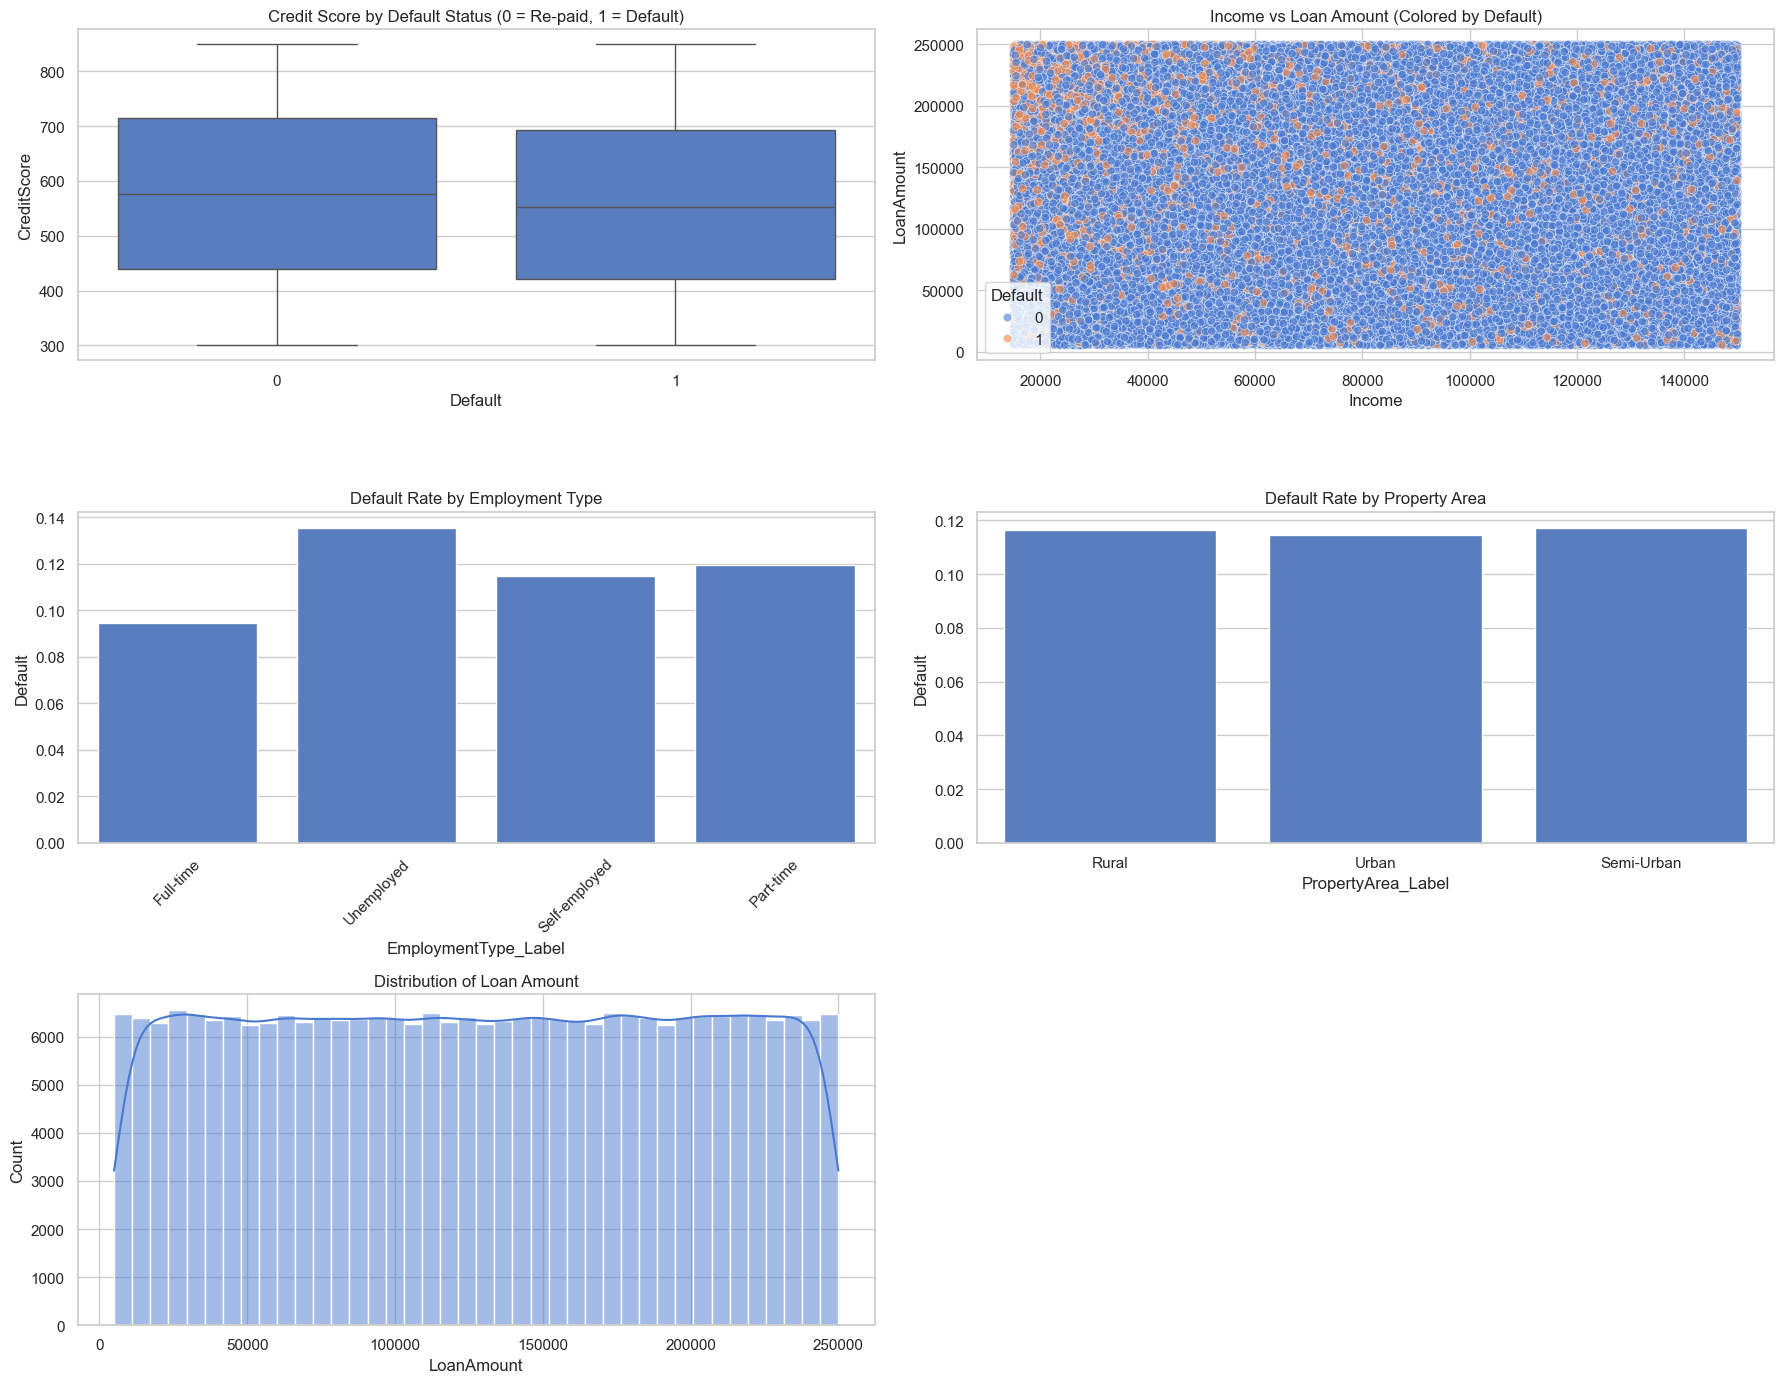

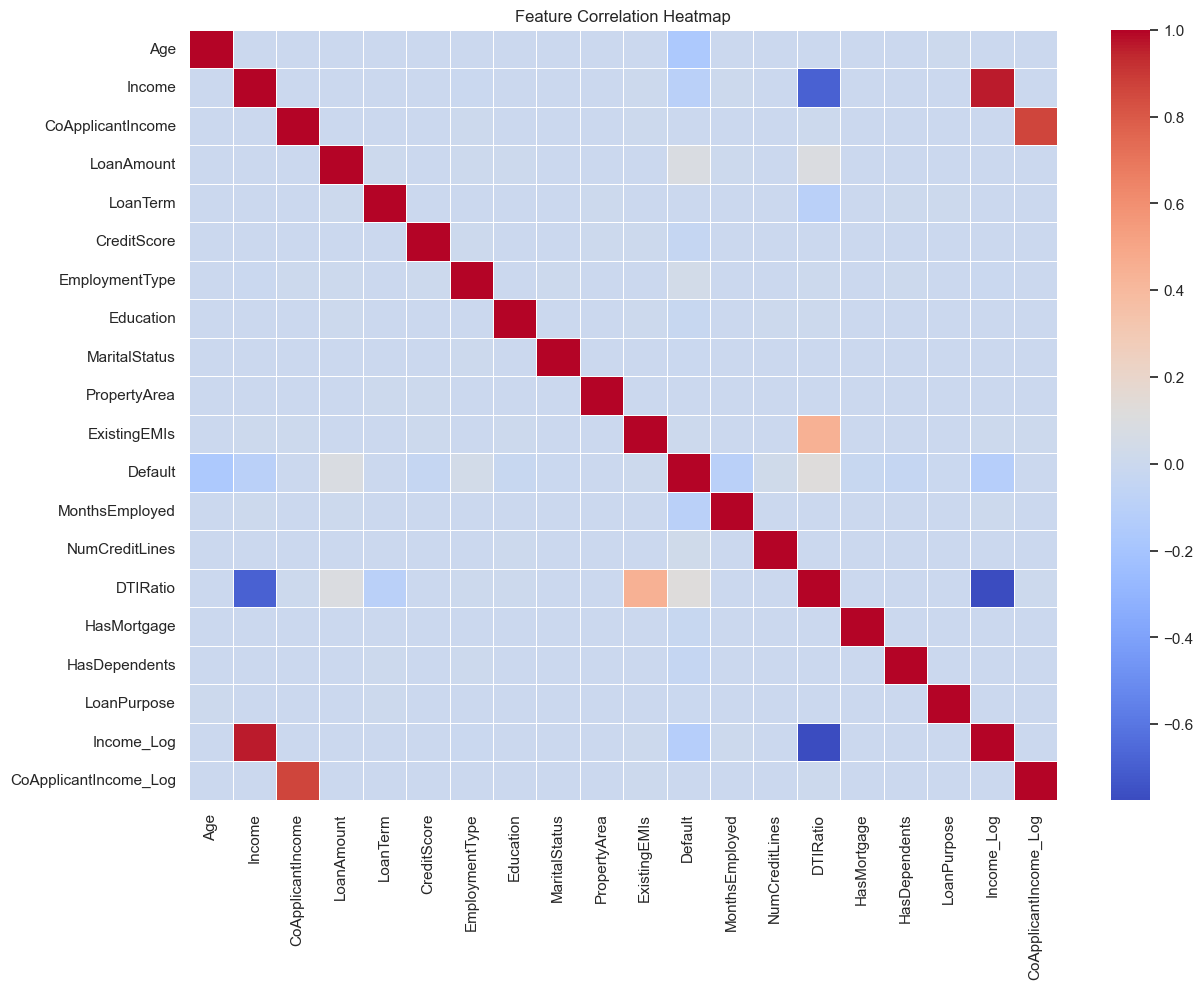

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(18, 14))

# 1. How does credit history affect loan approval?
plt.subplot(3, 2, 1)
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title('Credit Score by Default Status (0 = Re-paid, 1 = Default)')

# 2. Income vs Loan Amount Relationship
plt.subplot(3, 2, 2)
sns.scatterplot(x='Income', y='LoanAmount', hue='Default', data=df, alpha=0.6)
plt.title('Income vs Loan Amount (Colored by Default)')

# Set up a temporary dataframe with decoded labels for readability
df_eda = df.copy()
if 'EmploymentType' in le_dict:
    df_eda['EmploymentType_Label'] = le_dict['EmploymentType'].inverse_transform(df['EmploymentType'])
    df_eda['PropertyArea_Label'] = le_dict['PropertyArea'].inverse_transform(df['PropertyArea'])
else:
    df_eda['EmploymentType_Label'] = df['EmploymentType']
    df_eda['PropertyArea_Label'] = df['PropertyArea']

# 3. Default rate by Employment Type
plt.subplot(3, 2, 3)
sns.barplot(x='EmploymentType_Label', y='Default', data=df_eda, ci=None)
plt.title('Default Rate by Employment Type')
plt.xticks(rotation=45)

# 4. Risk comparison across Property Areas
plt.subplot(3, 2, 4)
sns.barplot(x='PropertyArea_Label', y='Default', data=df_eda, ci=None)
plt.title('Default Rate by Property Area')

# 5. Distribution of Loan Amount
plt.subplot(3, 2, 5)
sns.histplot(df['LoanAmount'], bins=40, kde=True)
plt.title('Distribution of Loan Amount')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [3]:
# Feature Engineering
df['Total_Income'] = df['Income'] + df['CoApplicantIncome']
df['Loan_to_Income_Ratio'] = df['LoanAmount'] / (df['Total_Income'] + 1)

# EMI-to-Income Ratio
# Formula: Monthly EMI = LoanAmount / (LoanTerm)
df['Monthly_EMI'] = df['LoanAmount'] / (df['LoanTerm'] + 1)
df['EMI_to_Income_Ratio'] = df['Monthly_EMI'] / ((df['Total_Income'] / 12) + 1)

# Income per dependent
df['Income_Per_Dependent'] = df['Total_Income'] / (df['HasDependents'].astype(int) + 1)

# Debt burden indicator
df['Debt_Burden'] = df['ExistingEMIs'] / (df['Total_Income'] / 12 + 1)


# Income Buckets
df['Income_Bucket'] = pd.qcut(df['Total_Income'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df['Income_Bucket_Encoded'] = LabelEncoder().fit_transform(df['Income_Bucket'])
df.drop('Income_Bucket', axis=1, inplace=True)
# Scale numerical features for better model performance
scaler = StandardScaler()
numeric_features = df.select_dtypes(include=[np.number]).columns
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# Prepare final dataset
df_final = df.copy()

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import os

# Separate features and target
X = df_final.drop('Default', axis=1)
# Recover original target by re-reading CSV if possible (avoids issues if `Default` was scaled)
csv_path = os.path.join(os.getcwd(), 'Loan_default.csv')
if os.path.exists(csv_path):
    temp_df = pd.read_csv(csv_path)
    y_raw = temp_df['Default']
else:
    y_raw = df_final['Default']

# Normalize target to binary integers
try:
    y_num = pd.to_numeric(y_raw)
    if y_num.nunique() > 2:
        # fallback: threshold at median
        y = (y_num > y_num.median()).astype(int)
    else:
        y = y_num.astype(int)
except Exception:
    y = y_raw.astype(str).str.strip().map({'No':0,'Yes':1,'N':0,'Y':1}).fillna(0).astype(int)

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
}

# Model training and evaluation
results = []
model_objects = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    model_objects[name] = model
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    # Calculate metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

Features shape: (255347, 26)
Target distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

MODEL COMPARISON TABLE
              Model  Accuracy  Precision   Recall  ROC-AUC
Logistic Regression  0.885177   0.624535 0.028326 0.725575
      Decision Tree  0.880771   0.396597 0.051088 0.693695
      Random Forest  0.884805   0.575000 0.031023 0.715758


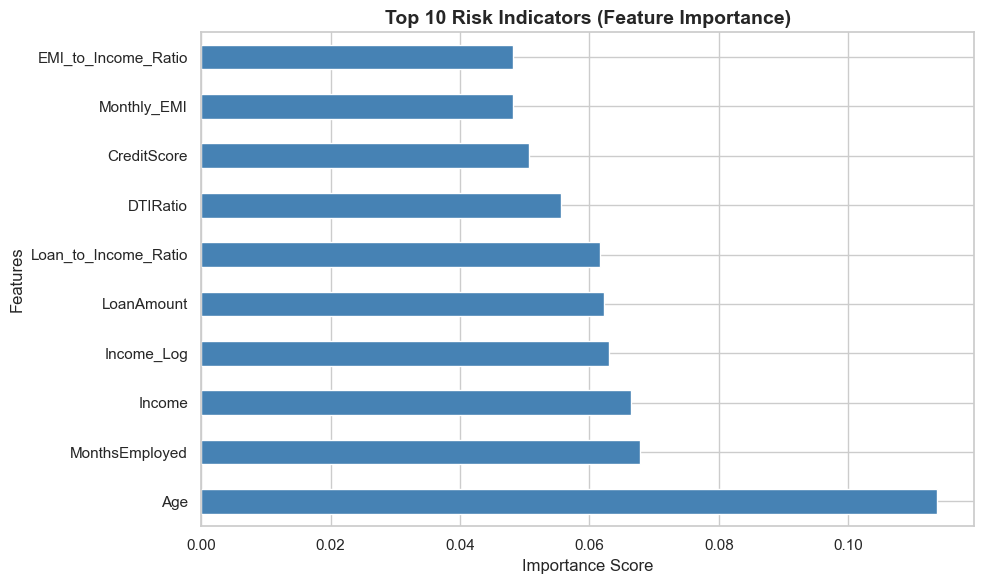


CONFUSION MATRIX - RANDOM FOREST
[[45003   136]
 [ 5747   184]]

True Negatives (Correct Non-Defaults): 45003
False Positives (Incorrect Defaults): 136
False Negatives (Missed Defaults): 5747
True Positives (Correct Defaults): 184

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Non-Default       0.89      1.00      0.94     45139
     Default       0.57      0.03      0.06      5931

    accuracy                           0.88     51070
   macro avg       0.73      0.51      0.50     51070
weighted avg       0.85      0.88      0.84     51070


TOP RISK INDICATORS (Factors that increase default probability)
1. Age: 0.1138
2. MonthsEmployed: 0.0679
3. Income: 0.0665
4. Income_Log: 0.0631
5. LoanAmount: 0.0623


In [5]:
# Model Explainability - Feature Importance
rf_model = model_objects["Random Forest"]
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.nlargest(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Risk Indicators (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Confusion Matrix Analysis
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

print("\n" + "="*70)
print("CONFUSION MATRIX - RANDOM FOREST")
print("="*70)
print(cm)
print(f"\nTrue Negatives (Correct Non-Defaults): {cm[0,0]}")
print(f"False Positives (Incorrect Defaults): {cm[0,1]}")
print(f"False Negatives (Missed Defaults): {cm[1,0]}")
print(f"True Positives (Correct Defaults): {cm[1,1]}")

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_rf, target_names=['Non-Default', 'Default']))

# Business Insights
print("\n" + "="*70)
print("TOP RISK INDICATORS (Factors that increase default probability)")
print("="*70)
for i, (feature, importance) in enumerate(feature_importance.head(5).items(), 1):
    print(f"{i}. {feature}: {importance:.4f}")